# Decision Tree vs Bagging vs Random Forest

| Feature | Decision Tree | Bagging | Random Forest |
|---------|---------------|----------|---------------|
| **Learning Type** | Single learner | Ensemble learning | Ensemble learning |
| **Base Model** | One Decision Tree | Multiple Decision Trees | Multiple Decision Trees |
| **Training Data** | Entire dataset | Bootstrap samples | Bootstrap samples |
| **Feature Selection** | All features at every split | All features at every split | Random subset of features at every split |
| **Aggregation** | Single prediction | Majority voting / Averaging | Majority voting / Averaging |
| **Bias** | Low | Low | Slightly higher than Bagging |
| **Variance** | High | Lower | Lowest |
| **Overfitting** | High | Reduced | Lowest |
| **Interpretability** | High | Low | Low |
| **Training Speed** | Fast | Moderate | Moderate |
| **Accuracy** | Good | Better | Usually Best |

---

<details>
<summary><strong>Decision Tree</strong></summary>

### How it works
1. Starts with the entire dataset.
2. Chooses the best feature using a criterion such as:
   - Gini Index
   - Entropy (Information Gain)
3. Splits the data into child nodes.
4. Repeats the process until a stopping condition is met.

### Characteristics
- Uses **100% of the training data**.
- Uses **all available features** when searching for the best split.
- Produces **one tree**.

### Advantages
- Very easy to understand and visualize.
- Fast to train.
- Requires little data preprocessing.
- Can model non-linear relationships.

### Disadvantages
- Easily overfits the training data.
- High variance (small data changes may create a completely different tree).
- Less stable than ensemble methods.

</details>

---

<details>
<summary><strong>Bagging (Bootstrap Aggregating)</strong></summary>

### Main Idea
Instead of relying on **one tree**, train **many Decision Trees** and combine their predictions.

### How it works
1. Create multiple **bootstrap samples** from the original dataset.
2. Train one Decision Tree on each sample.
3. Each tree uses **all features** when splitting.
4. Combine predictions:
   - **Classification:** Majority Voting
   - **Regression:** Average Prediction

### Bootstrap Sampling
- Random sampling **with replacement**.
- Some samples may appear multiple times.
- Some samples may not appear at all.

### Why it works
Each tree sees a slightly different dataset, reducing variance and making the final prediction more stable.

### Advantages
- Reduces overfitting.
- More stable than a single Decision Tree.
- Better generalization.

### Disadvantages
- Trees are still highly correlated because they all use the same features.
- Slower than a single Decision Tree.
- Hard to interpret.

</details>

---

<details>
<summary><strong>Random Forest</strong></summary>

### Main Idea
Random Forest improves Bagging by making the trees **less similar**.

### How it works
1. Create bootstrap samples.
2. Train many Decision Trees.
3. At every split:
   - Randomly choose only a subset of features.
   - Find the best split using only those selected features.
4. Combine predictions:
   - **Classification:** Majority Voting
   - **Regression:** Average Prediction

### Random Feature Selection
Suppose the dataset has **10 features**.

Instead of checking all 10 features:

- Tree 1 may check only Features {2, 5, 8}
- Tree 2 may check only Features {1, 3, 7}
- Tree 3 may check only Features {4, 6, 9}

This creates more diverse trees.

### Why it performs better
Bagging reduces variance by changing the data.

Random Forest reduces variance **even more** by changing:
- the training data (bootstrap samples)
- the features considered at each split

This lowers the correlation between trees and improves generalization.

### Advantages
- High accuracy.
- Excellent generalization.
- Resistant to overfitting.
- Handles high-dimensional datasets.
- Provides feature importance.
- Robust to noise and outliers.

### Disadvantages
- Slower than a single Decision Tree.
- Requires more memory.
- Harder to interpret.
- Training time increases as the number of trees grows.

</details>

---

<details>
<summary><strong>Bagging vs Random Forest</strong></summary>

| Property | Bagging | Random Forest |
|----------|----------|---------------|
| Bootstrap Sampling | Yes | Yes |
| Random Feature Selection | No | Yes |
| Tree Correlation | Higher | Lower |
| Variance | Low | Lower |
| Overfitting | Reduced | Further Reduced |
| Accuracy | High | Usually Higher |

### Key Difference

**Bagging**

```text
Different Data
        ↓
 Decision Trees
        ↓
 Majority Vote
```

**Random Forest**

```text
Different Data
        +
Random Features
        ↓
 Decision Trees
        ↓
 Majority Vote
```

Random Forest is essentially **Bagging + Random Feature Selection**.

</details>

---

<details>
<summary><strong>When to Use Each</strong></summary>

| Model | Best Use Case |
|--------|---------------|
| Decision Tree | Small datasets where interpretability is important. |
| Bagging | Improve the stability of Decision Trees while keeping the algorithm simple. |
| Random Forest | Best default choice for most classification and regression problems. |

</details>

---

## Final Summary

- **Decision Tree:** One tree using the entire dataset and all features. Fast and interpretable, but prone to overfitting.
- **Bagging:** Many Decision Trees trained on different bootstrap samples. Reduces variance through majority voting.
- **Random Forest:** Bagging + random feature selection at every split. Produces more diverse trees, reduces overfitting further, and usually achieves the best performance.

In [ ]:
# Import Libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


# Display all columns of dataframe despite the large number of these columns 
pd.set_option("display.max_columns", None)

In [ ]:
# Load Dataset
data=load_breast_cancer()

X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="Target")

df=X.copy()
df['Target']=y

df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
# Explore Dataset
print("Dataset shape:", df.shape)
print("Number of features:", X.shape[1])
print("Target names:", data.target_names)
print("Missing values:", df.isnull().sum().sum())
print("Class counts:")
print(y.value_counts().sort_index())

Dataset shape: (569, 31)
Number of features: 30
Target names: ['malignant' 'benign']
Missing values: 0
Class counts:
Target
0    212
1    357
Name: count, dtype: int64


In [15]:
# Split The data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 426
Testing samples: 143


# Decision Tree
A single Decision Tree may learn the training data in too much detail, causing overfitting and high variance.

In [21]:

tree=DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)
tree_train_pred=tree.predict(X_train)
tree_test_pred=tree.predict(X_test)

print("Training Accuracy : ",accuracy_score(y_train,tree_train_pred))
print("Testing Accuracy : ",accuracy_score(y_test,tree_test_pred))


print("\nClassification Report of Decision Tree :")
print(classification_report(
    y_test,
    tree_test_pred,
    target_names=["Malignant", "Benign"]
))


Training Accuracy :  1.0
Testing Accuracy :  0.9230769230769231

Classification Report of Decision Tree :
              precision    recall  f1-score   support

   Malignant       0.88      0.92      0.90        53
      Benign       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



### Bootstrap Sampling

- A random sampling technique **with replacement**.
- Each sample is selected randomly, then **returned to the dataset** before the next selection.
- Some samples may appear **multiple times**, while others may **not appear at all**.
- Used in **Bagging** and **Random Forest** to train each Decision Tree on a slightly different dataset, reducing overfitting and improving generalization.

In [28]:
original_data=pd.DataFrame({"Row_Id":list(range(1,11))})

bootstrap_sample=original_data.sample(n=len(original_data),replace=True,random_state=42)

# T -> return the transpose of dataframe if it 10x1 it will be 1x10
print("Original data:")
# Display function it's a jupyter format function display dataframe in formatted HTML table
display(original_data.T)

print("Bootstrap sample:")
display(bootstrap_sample.reset_index(drop=True).T)



Original data:


,0,1,2,3,4,5,6,7,8,9
Row_Id,1,2,3,4,5,6,7,8,9,10


Bootstrap sample:


,0,1,2,3,4,5,6,7,8,9
Row_Id,7,4,8,5,7,10,3,7,8,5


# Bagging 
Bagging trains multiple Decision Trees on different Bootstrap Samples, then combines their predictions using Majority Voting.

In [31]:
# Create Bagging Classifier that use 100 decision tree
bagging=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), # Specifies the base model used in Bagging
                          random_state=42, # Ensures you get the same bootstrap samples every time you run the code.
                          n_estimators=100, # Number of decision trees 
                          bootstrap=True, # with replacement
                          n_jobs=-1 # Uses all available CPU cores to train the trees in parallel.
                          )

bagging.fit(X_train,y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_test_pred = bagging.predict(X_test)


print("Training Accuracy:", accuracy_score(y_train, bagging_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, bagging_test_pred))

print("\nClassification Report of Bagging :")
print(classification_report(
    y_test,
    bagging_test_pred,
    target_names=["Malignant", "Benign"]
))


Training Accuracy: 1.0
Testing Accuracy: 0.951048951048951

Classification Report of Bagging :
              precision    recall  f1-score   support

   Malignant       0.94      0.92      0.93        53
      Benign       0.96      0.97      0.96        90

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



# Random Forest

Random Forest adds another source of randomness:

1. Different Bootstrap Samples.
2. Random subsets of features at each split.

This reduces correlation between trees.


In [32]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)
rf_train_pred = random_forest.predict(X_train)
rf_test_pred = random_forest.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, rf_test_pred))


print("\nClassification Report of Random Forest :")
print(classification_report(
    y_test,
    rf_test_pred,
    target_names=["Malignant", "Benign"]
))


Training Accuracy: 1.0
Testing Accuracy: 0.958041958041958

Classification Report of Random Forest :
              precision    recall  f1-score   support

   Malignant       0.96      0.92      0.94        53
      Benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



# compare Models 

In [42]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

comparison = pd.DataFrame([
    evaluate_model("Decision Tree", y_test, tree_test_pred),
    evaluate_model("Bagging", y_test, bagging_test_pred),
    evaluate_model("Random Forest", y_test, rf_test_pred)
])

comparison.sort_values(by='F1-score',ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.958042,0.956522,0.977778,0.967033
1,Bagging,0.951049,0.956044,0.966667,0.961326
2,Decision Tree,0.923077,0.954023,0.922222,0.937853


# Plot Model comaparison

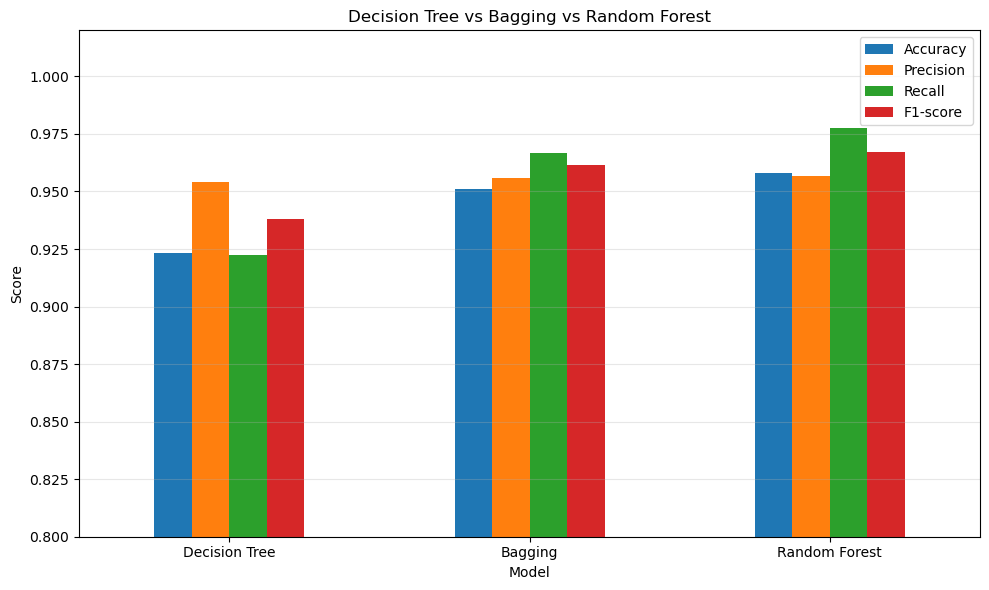

In [ ]:
# Makes the Model column become the DataFrame index
# When plotting, Pandas uses the index as the labels on the x-axis
comparison.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.ylim(0.80, 1.02)
plt.ylabel("Score")
plt.title("Decision Tree vs Bagging vs Random Forest")
plt.xticks(rotation=0) # instead of vertical appearance make it horizontal
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Confusion Matrices

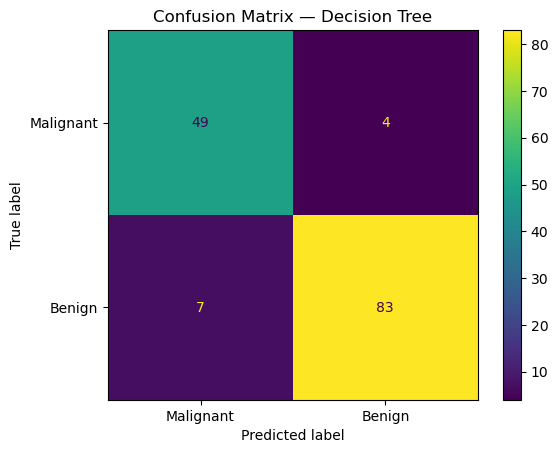

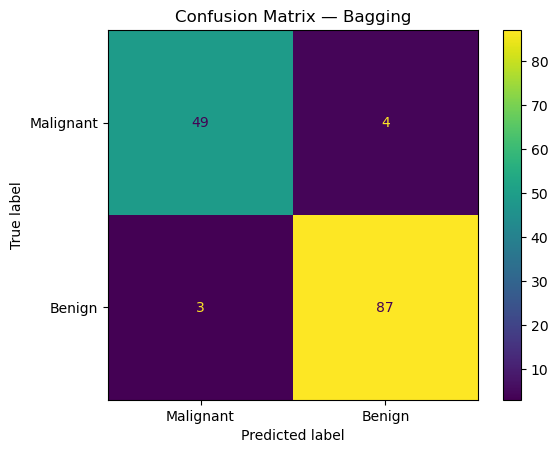

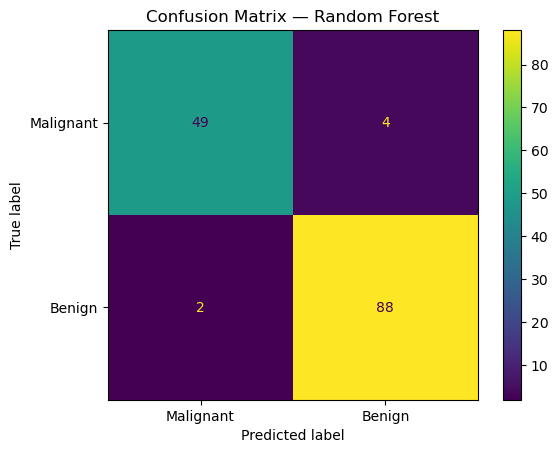

In [47]:
all_predictions = {
    "Decision Tree": tree_test_pred,
    "Bagging": bagging_test_pred,
    "Random Forest": rf_test_pred
}

for model_name, predictions in all_predictions.items():
    cm = confusion_matrix(y_test, predictions)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant", "Benign"]
    ).plot()
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

# Effect of Number of Trees

In [48]:
tree_counts = [1, 5, 10, 20, 50, 100, 200]
bagging_scores = []
forest_scores = []

for count in tree_counts:
    temp_bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=count,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    temp_bagging.fit(X_train, y_train)
    bagging_scores.append(accuracy_score(y_test, temp_bagging.predict(X_test)))

    temp_forest = RandomForestClassifier(
        n_estimators=count,
        random_state=42,
        n_jobs=-1
    )
    temp_forest.fit(X_train, y_train)
    forest_scores.append(accuracy_score(y_test, temp_forest.predict(X_test)))

tree_results = pd.DataFrame({
    "NumberOfTrees": tree_counts,
    "BaggingAccuracy": bagging_scores,
    "RandomForestAccuracy": forest_scores
})

tree_results

,NumberOfTrees,BaggingAccuracy,RandomForestAccuracy
0,1,0.923077,0.923077
1,5,0.951049,0.937063
2,10,0.944056,0.951049
3,20,0.958042,0.958042
4,50,0.951049,0.951049
5,100,0.951049,0.958042
6,200,0.951049,0.958042


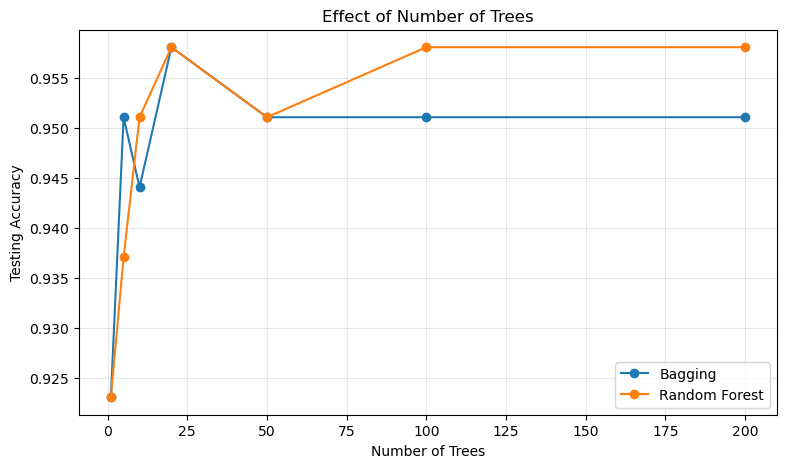

In [49]:
plt.figure(figsize=(9, 5))
plt.plot(tree_results["NumberOfTrees"], tree_results["BaggingAccuracy"], marker="o", label="Bagging")
plt.plot(tree_results["NumberOfTrees"], tree_results["RandomForestAccuracy"], marker="o", label="Random Forest")
plt.xlabel("Number of Trees")
plt.ylabel("Testing Accuracy")
plt.title("Effect of Number of Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Random Forest Feature Importance

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(10)


,Feature,Importance
23,worst area,0.149674
27,worst concave points,0.127189
7,mean concave points,0.104650
20,worst radius,0.086963
22,worst perimeter,0.080299
2,mean perimeter,0.080037
6,mean concavity,0.055420
0,mean radius,0.053665
3,mean area,0.044062
13,area error,0.024557
